#Production of a particle with a given mass and momentum spectrum is followed by simulation of its two-body decay.


In [9]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

# Physical constants (MeV, c=1)

M_PI = 139.57018
M_MU = 105.65837
M_E  = 0.51100
M_NU = 0.0

N_EVENTS = 500000  # events per decay mode

If we take the branching method where 99.987% of the decay happens via the muon pathway,I was only getting 65 samples for the electron pathway per 500000 samples which was very less for me to produce the graphs of required manner
so to counter that , I am taking 500000 sampels per pathway for better graphs.

## Core Simulation Function

In [10]:

def simulate_decay(n_events, m_daughter1, m_daughter2):
    """
    Simulates two-body pion decay:
        pion -> B + C

    returns dictionary of kinematic observables.
    """

    # Pion properties in LAB frame
    pion_mass = np.random.normal(M_PI, 0.00035, n_events) # for normal distribution of mass of pion as per paper
    pion_momentum = np.random.exponential(scale=80.0, size=n_events) #avg pion momentum is 80 MeV

    pion_energy = np.sqrt(pion_mass**2 + pion_momentum**2) #c = 1
    gamma = pion_energy / pion_mass
    beta = pion_momentum / pion_energy

    # CM frame kinematics
    term = (pion_mass**2 - (m_daughter1 + m_daughter2)**2) * (pion_mass**2 - (m_daughter1 - m_daughter2)**2)

    p_cm = np.sqrt(np.maximum(term, 0)) / (2 * pion_mass)

    E1_cm = np.sqrt(m_daughter1**2 + p_cm**2)
    E2_cm = np.sqrt(m_daughter2**2 + p_cm**2)

    # Isotropic decay
    cos_theta_cm = np.random.uniform(-1, 1, n_events)
    sin_theta_cm = np.sqrt(1 - cos_theta_cm**2)
    theta_cm = np.degrees(np.arccos(cos_theta_cm))

    # Momentum components (CM)
    # equation 5 in paper
    p1_par = p_cm * cos_theta_cm #parallel
    p1_perp = p_cm * sin_theta_cm #perpendicular

    # equation 6 in paper
    p2_par = -p_cm * cos_theta_cm #parallel
    p2_perp = p_cm * sin_theta_cm #perpendicular

    # Boost to LAB frame

    def boost(p_par, p_perp, E_cm):
        p_par_lab = gamma * p_par + beta * gamma * E_cm
        p_perp_lab = p_perp
        p_lab = np.sqrt(p_par_lab**2 + p_perp_lab**2)
        return p_par_lab, p_perp_lab, p_lab

    p1_par_lab, p1_perp_lab, p1_lab = boost(p1_par, p1_perp, E1_cm)
    p2_par_lab, p2_perp_lab, p2_lab = boost(p2_par, p2_perp, E2_cm)

    # LAB angles
    def lab_angle(p_par, p_total):
        return np.degrees(np.arccos(
            np.clip(p_par / np.maximum(p_total, 1e-12), -1, 1)
        ))

    theta1_lab = lab_angle(p1_par_lab, p1_lab)
    theta2_lab = lab_angle(p2_par_lab, p2_lab)

    # Opening angle
    dot_product = p1_par_lab * p2_par_lab - p1_perp_lab * p2_perp_lab
    cos_open = dot_product / np.maximum(p1_lab * p2_lab, 1e-12)
    cos_open = np.clip(cos_open, -1, 1)

    opening_angle = np.degrees(np.arccos(cos_open))

    return {
        "pion_momentum": pion_momentum,
        "theta_cm": theta_cm,
        "p1_lab": p1_lab,
        "p2_lab": p2_lab,
        "theta1_lab": theta1_lab,
        "theta2_lab": theta2_lab,
        "opening_angle": opening_angle,
    }


##Actual Simulations

In [11]:
print("Simulating pion -> muon + neutrino")
mu_data = simulate_decay(N_EVENTS, M_MU, M_NU)

print("Simulating pion → electron + neutrino")
e_data = simulate_decay(N_EVENTS, M_E, M_NU)

print("Simulation complete.\n")

Simulating pion -> muon + neutrino
Simulating pion → electron + neutrino
Simulation complete.



##Plotting Helper Function

In [12]:

def plot_results(data, label):
    """
    Generates 6-panel plot identical to original.
    """

    p_pi = data["pion_momentum"]
    theta_cm = data["theta_cm"]
    p1 = data["p1_lab"]
    p2 = data["p2_lab"]
    theta1 = data["theta1_lab"]
    theta2 = data["theta2_lab"]
    opening = data["opening_angle"]

    fig, axes = plt.subplots(3, 2, figsize=(11, 13))
    fig.suptitle(f"Kinematics: pion → {label} + neutrino", fontsize=13)

    # (a) Pion momentum
    axes[0, 0].hist(p_pi, bins=80, range=(0, 500),
                    histtype="step")
    axes[0, 0].set_yscale("log")
    axes[0, 0].set_title("(a) Pion momentum")

    #histtype had step,bar,barstaked and stepfilled

    # (b) CM angle
    axes[0, 1].hist(theta_cm, bins=60, range=(0, 180),
                    density=True, histtype="step")
    axes[0, 1].set_title("(b) CM angle")

    # (c) LAB momenta
    axes[1, 0].hist(p1, bins=80, range=(0, 500),
                    histtype="step", label=label)
    axes[1, 0].hist(p2, bins=80, range=(0, 500),
                    histtype="step", linestyle="dashed", label="neutrino")
    axes[1, 0].set_yscale("log")
    axes[1, 0].legend()
    axes[1, 0].set_title("(c) LAB momentum")

    # (d) LAB angles
    axes[1, 1].hist(theta1, bins=60, range=(0, 180),
                    histtype="step", label=label)
    axes[1, 1].hist(theta2, bins=60, range=(0, 180),
                    histtype="step", linestyle="dashed", label="neutrino")
    axes[1, 1].set_yscale("log")
    axes[1, 1].legend()
    axes[1, 1].set_title("(d) LAB angles")

    # (e) Opening angle
    axes[2, 0].hist(opening, bins=60, range=(0, 180),
                    density=True, histtype="step")
    axes[2, 0].set_title("(e) Opening angle")

    # (f) Avg opening vs momentum
    bins = np.arange(0, 505, 10)
    centers = (bins[:-1] + bins[1:]) / 2

    avg_opening = []
    for i in range(len(bins) - 1):
        mask = (p_pi >= bins[i]) & (p_pi < bins[i+1])
        avg_opening.append(
            np.mean(opening[mask]) if np.sum(mask) > 10 else np.nan
        )

    #np.nan avoids unreasonable values(lookup)

    axes[2, 1].plot(centers, avg_opening)
    axes[2, 1].set_title("(f) Avg opening vs momentum")

    plt.tight_layout()
    plt.show()



##Final plots

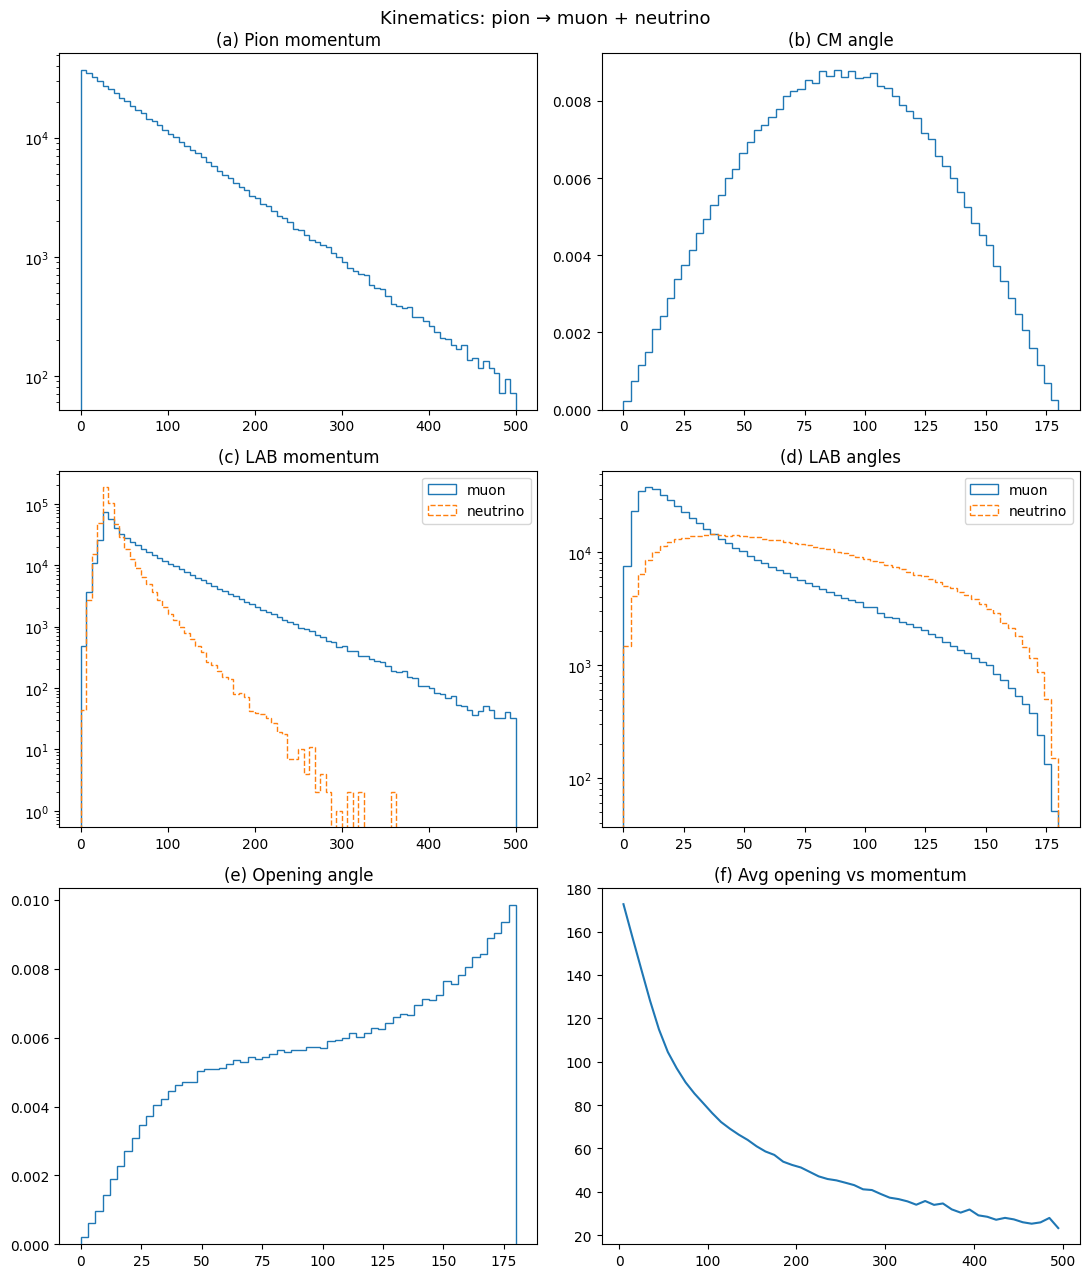

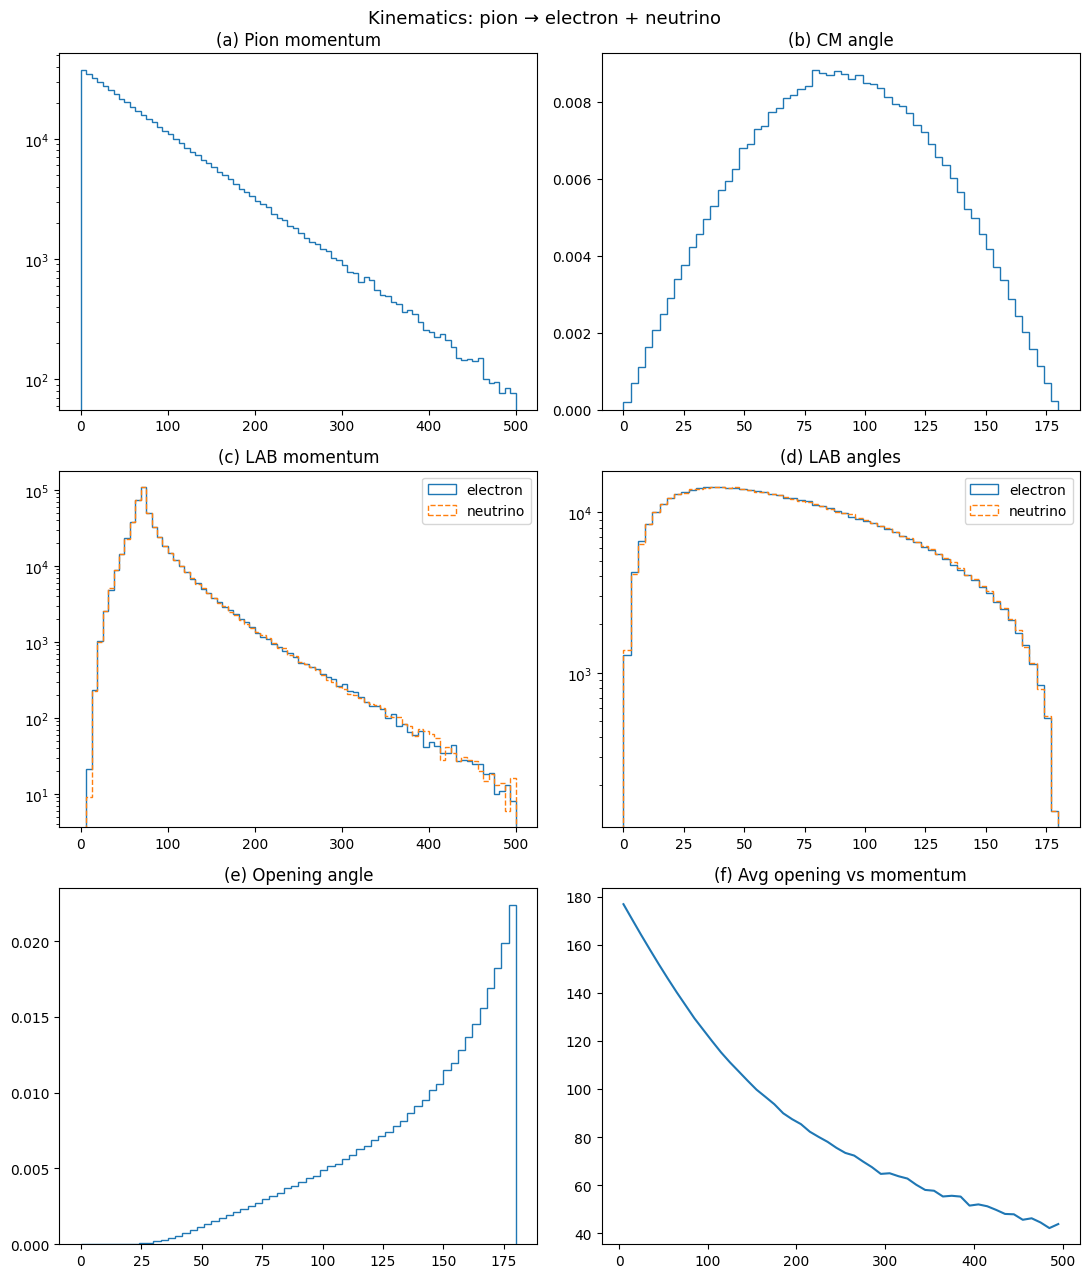

In [13]:

# Generate plots

plot_results(mu_data, "muon")
plot_results(e_data, "electron")



# Radioactivity Simulations


Running radioactive decay simulation.
Simulating decay cases...
Done.


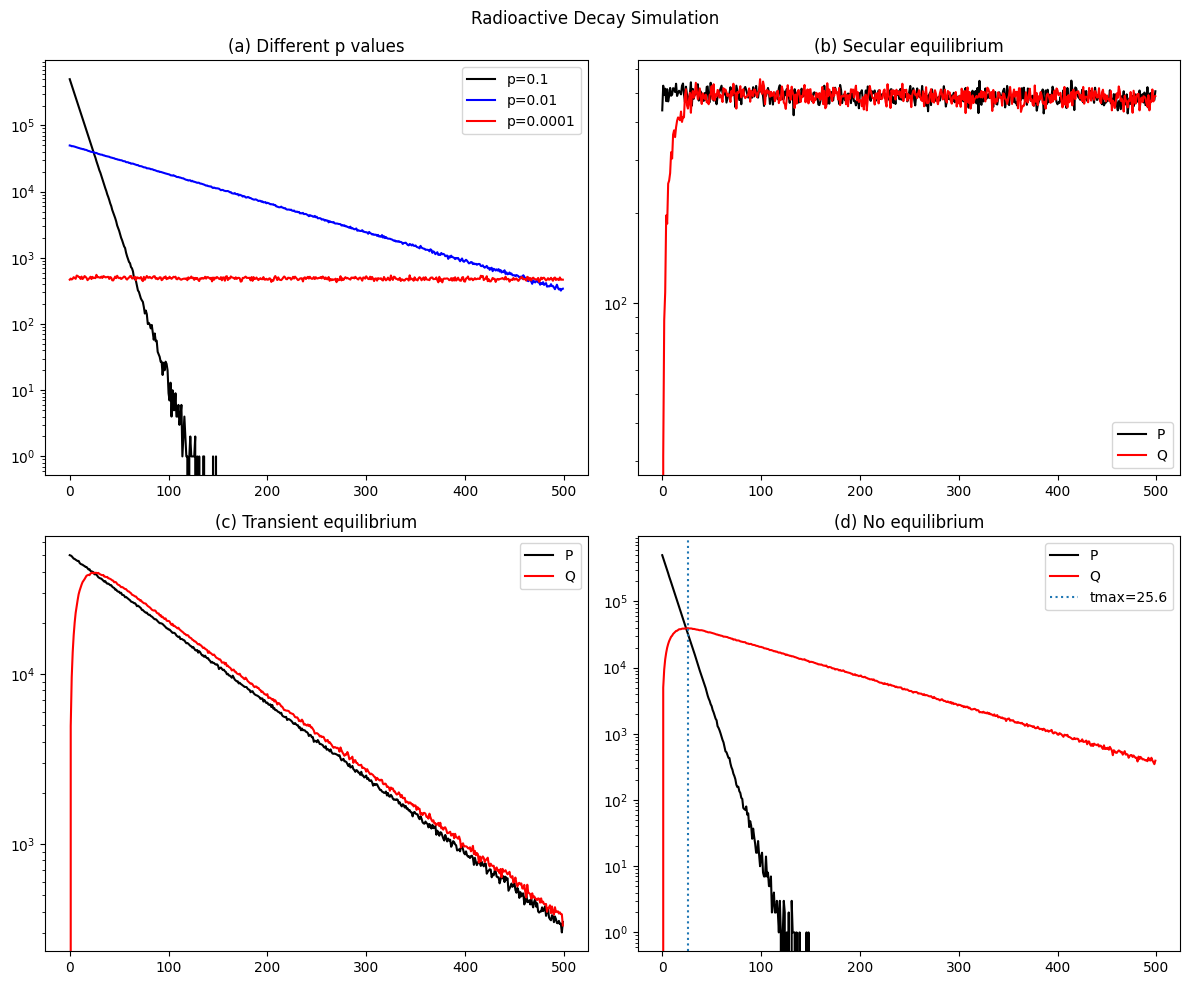

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\nRunning radioactive decay simulation.")

N_NUCLEI  = 5000000
NUM_STEPS = 500
time_axis = np.arange(NUM_STEPS)


# Core Simulations
def simulate_decay(N, p): #simulating normal decay
    activities = []
    for i in range(NUM_STEPS):
        decayed = np.random.binomial(N, p)
        activities.append(decayed)
        N = max(N - decayed, 0)
    return np.array(activities)


def simulate_series(NP, pP, pQ):
    NQ, NR = 0, 0
    act_P, act_Q = [], []

    for i in range(NUM_STEPS):
        dP = np.random.binomial(NP, pP)
        dQ = np.random.binomial(NQ, pQ)

        act_P.append(dP)
        act_Q.append(dQ)

        NP = max(NP - dP, 0)
        NQ = max(NQ + dP - dQ, 0)
        NR += dQ

    return np.array(act_P), np.array(act_Q)


# Simulations
print("Simulating decay cases...")

# Single decay
p_values = [0.1, 0.01, 0.0001]
single_decay = [simulate_decay(N_NUCLEI, p) for p in p_values]

# Series cases
cases = {
    "Secular":   (0.0001, 0.1), # lambda q >> lambda p
    "Transient": (0.01,   0.1), # lambda q > lambda p
    "NoEq":      (0.1,    0.01) # lambda q < lambda p
}

series_results = {
    name: simulate_series(N_NUCLEI, pP, pQ)
    for name, (pP, pQ) in cases.items()
}

print("Done.")


# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Radioactive Decay Simulation")

# (a) Single decay
ax = axes[0, 0]
colors = ["black", "blue", "red"]
for p, act, c in zip(p_values, single_decay, colors):
    ax.plot(time_axis, act, color=c, label=f"p={p}")
ax.set_yscale("log")
ax.set_title("(a) Different p values")
ax.legend()

# Helper plot for series
def plot_series(ax, actP, actQ, title):
    ax.plot(time_axis, actP, label="P", color="black")
    ax.plot(time_axis, actQ, label="Q", color="red")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.legend()


# (b), (c), (d)
plot_series(axes[0, 1], *series_results["Secular"],   "(b) Secular equilibrium")
plot_series(axes[1, 0], *series_results["Transient"], "(c) Transient equilibrium")
plot_series(axes[1, 1], *series_results["NoEq"],      "(d) No equilibrium")

# t_max for no equilibrium
pP, pQ = cases["NoEq"]
tmax = np.log(pP / pQ) / (pP - pQ)
axes[1, 1].axvline(tmax, linestyle="dotted", label=f"tmax={tmax:.1f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()